# Part 2.3: Analyzing Data Directly from S3

In [1]:
from pathlib import Path

import boto3
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

NETID = "yg452"
MY_BUCKET = f"dsan6000-{NETID}"
DEST_PREFIX = "wikipedia-hourly"
IMAGE_DIR = Path("images")
IMAGE_DIR.mkdir(exist_ok=True)

s3 = boto3.client("s3")

In [2]:
keys = sorted(
    obj["Key"]
    for page in s3.get_paginator("list_objects_v2").paginate(
        Bucket=MY_BUCKET, Prefix=f"{DEST_PREFIX}/"
    )
    for obj in page.get("Contents", [])
    if obj["Key"].endswith(".parquet")
)
print(len(keys), "files")

24 files


In [3]:
hourly_dfs = []
for key in keys:
    hour_df = pd.read_parquet(f"s3://{MY_BUCKET}/{key}")
    hour_df["hour"] = pd.to_datetime(Path(key).stem, format="%Y%m%d_%H%M%S")
    hourly_dfs.append(hour_df)

df = pd.concat(hourly_dfs, ignore_index=True)
print(df.shape)
df.head()

(119708, 30)


,datetime,$schema,meta,id,type,namespace,title,title_url,comment,timestamp,...,parsedcomment,log_id,log_type,log_action,log_params,log_action_comment,patrolled,file_ts,file_ts_str,hour
0,2026-09-01 04:00:02,/mediawiki/recentchange/1.0.0,{'uri': 'https://en.wikipedia.org/wiki/Jake_O%...,2.063884e+09,edit,0,Jake O'Donnell,https://en.wikipedia.org/wiki/Jake_O%27Donnell,Fix dash,1788235202,...,Fix dash,NaN,NaN,NaN,NaN,NaN,None,2026-09-01 04:00:00,20260901_040000,2026-09-01 04:00:00
1,2026-09-01 04:00:02,/mediawiki/recentchange/1.0.0,{'uri': 'https://en.wikipedia.org/wiki/Beverid...,2.063884e+09,edit,0,Beveridge Award,https://en.wikipedia.org/wiki/Beveridge_Award,Add source,1788235202,...,Add source,NaN,NaN,NaN,NaN,NaN,None,2026-09-01 04:00:00,20260901_040000,2026-09-01 04:00:00
2,2026-09-01 04:00:01,/mediawiki/recentchange/1.0.0,{'uri': 'https://en.wikipedia.org/wiki/1920_Un...,2.063884e+09,edit,0,1920 United States presidential election in Wa...,https://en.wikipedia.org/wiki/1920_United_Stat...,/* Counties that flipped from Democratic to Re...,1788235201,...,"<span class=""autocomment""><a href=""/wiki/1920_...",NaN,NaN,NaN,NaN,NaN,None,2026-09-01 04:00:00,20260901_040000,2026-09-01 04:00:00
3,2026-09-01 04:00:02,/mediawiki/recentchange/1.0.0,{'uri': 'https://en.wikipedia.org/wiki/1987_Ae...,2.063884e+09,edit,0,1987 Aegean crisis,https://en.wikipedia.org/wiki/1987_Aegean_crisis,added a bit of context,1788235202,...,added a bit of context,NaN,NaN,NaN,NaN,NaN,None,2026-09-01 04:00:00,20260901_040000,2026-09-01 04:00:00
4,2026-09-01 04:00:03,/mediawiki/recentchange/1.0.0,{'uri': 'https://en.wikipedia.org/wiki/Marvin_...,2.063884e+09,edit,0,Marvin Schwäbe,https://en.wikipedia.org/wiki/Marvin_Schw%C3%A4be,NaN,1788235203,...,NaN,NaN,NaN,NaN,NaN,NaN,None,2026-09-01 04:00:00,20260901_040000,2026-09-01 04:00:00


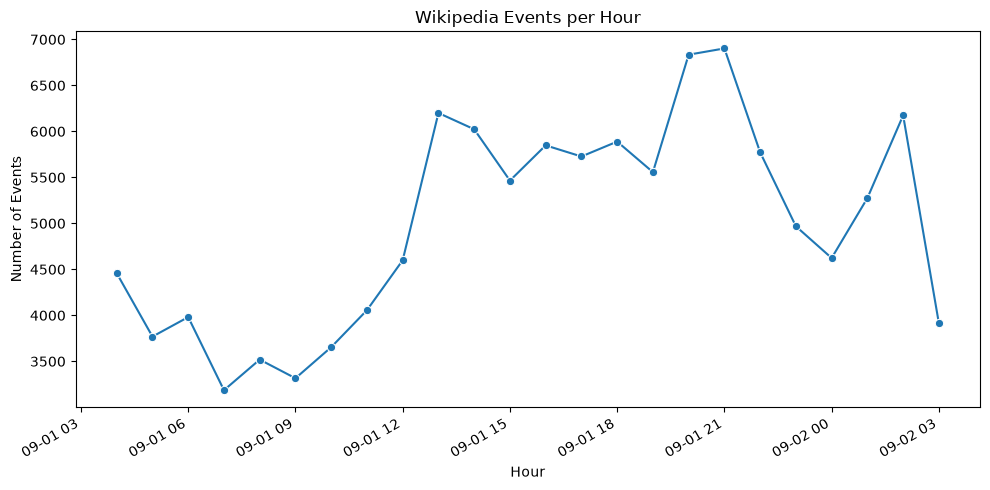

In [4]:
hourly_counts = df.groupby("hour").size().reset_index(name="num_events")

fig, ax = plt.subplots(figsize=(10, 5))
sns.lineplot(data=hourly_counts, x="hour", y="num_events", marker="o", ax=ax)
ax.set(title="Wikipedia Events per Hour", xlabel="Hour", ylabel="Number of Events")
fig.autofmt_xdate()
fig.tight_layout()
fig.savefig(IMAGE_DIR / "hourly-events.svg")
fig.savefig(IMAGE_DIR / "hourly-events.png", dpi=150)
plt.show()

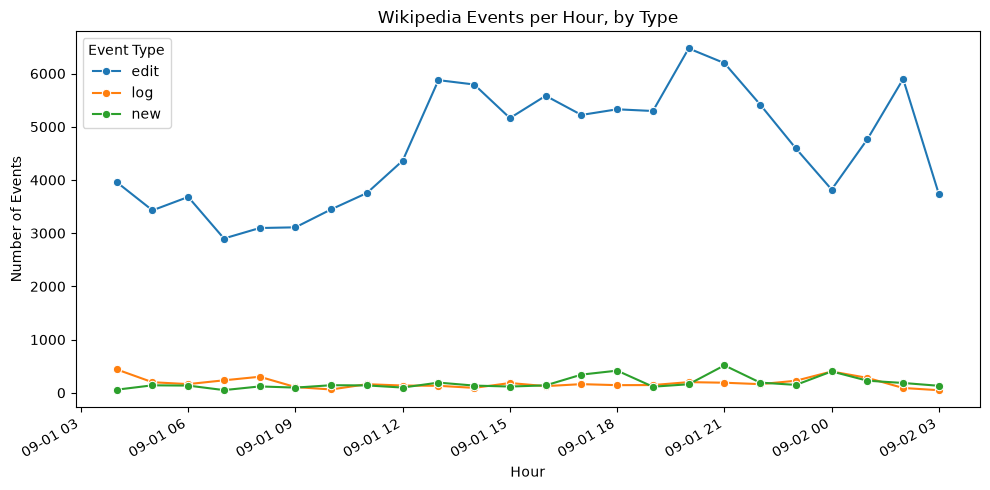

In [5]:
type_counts = df.groupby(["hour", "type"]).size().reset_index(name="num_events")

fig, ax = plt.subplots(figsize=(10, 5))
sns.lineplot(data=type_counts, x="hour", y="num_events", hue="type", marker="o", ax=ax)
ax.set(title="Wikipedia Events per Hour, by Type", xlabel="Hour", ylabel="Number of Events")
ax.legend(title="Event Type")
fig.autofmt_xdate()
fig.tight_layout()
fig.savefig(IMAGE_DIR / "events-by-type.svg")
fig.savefig(IMAGE_DIR / "events-by-type.png", dpi=150)
plt.show()